In [1]:
import source.helpers
import biolib
from pathlib import Path
import pandas as pd

from source import analysis, data, predict, regions
from source import path_method as pm

C:\Users\domin\anaconda3\envs\GLUT\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


2025-08-30 19:24:30,833 | INFO : Note: NumExpr detected 20 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
2025-08-30 19:24:30,835 | INFO : NumExpr defaulting to 16 threads.


In [2]:
# some libraries that might be neeeded
#pip install pymissense
#pip3 install --upgrade pybiolib 
#pip install gunicorn

In [3]:
proteins = {
'GLUT1':'P11166',
'GLUT2':'P11168',
'GLUT3':'P11169',
#'GLUT4':'P14672',
#'GLUT5':'P22732',
#'GLUT6':'Q9UGQ3',
#'GLUT7':'Q6PXP3',
#'GLUT8':'Q9NY64',
#'GLUT9':'Q9NRM0',
#'GLUT10':'O95528',
#'GLUT11':'Q9BYW1',
#'GLUT12':'Q8TD20',
#'GLUT13':'Q96QE2',
#'GLUT14':'Q8TDB8' 
}

## get data

In [4]:
RES_DIR = Path.cwd() / 'results'
DATA_DIR = Path.cwd() / 'data'

#if results and data direcotries not exists create them
Path.mkdir(RES_DIR, exist_ok=True)
Path.mkdir(DATA_DIR, exist_ok=True)

In [5]:
#import pdb and fasta files
PDB_DIR = DATA_DIR / 'pdb'
FAS_DIR = DATA_DIR / 'fasta'

Path.mkdir(PDB_DIR, exist_ok=True)
Path.mkdir(FAS_DIR, exist_ok=True)
for up_id in proteins.values():
    
    data.get_pdb(up_id, PDB_DIR / f'{up_id}.pdb')
    data.get_fasta(up_id,FAS_DIR / f'{up_id}.fasta')

## get predictions for proteins

In [6]:
alpha_missense_tsv = DATA_DIR / 'AlphaMissense_aa_substitutions.tsv'
data.get_alphamissense(alpha_missense_tsv)

AlphaMissense data already exists


In [7]:
# run pymissense for all proteins and generate csv of aminoacid pathogenicities

PYM_DIR = RES_DIR / 'pymissense'
Path.mkdir(PYM_DIR, exist_ok=True)

for up_id in proteins.values():
    pdb_file = PDB_DIR / f'{up_id}.pdb'
    
    print(f'running PyMissense for {up_id}')
    predict.pymissense(alpha_missense_tsv, pdb_file, up_id, PYM_DIR)

running PyMissense for P11166
running PyMissense for P11168
running PyMissense for P11169


## get protein regions

In [8]:
reg_prefix = {'all':'all',
            'intracellular':'I',
            'extracellular':'O',
            'membrane':'M',
            'binding pocket':'bp',
            'lining residues':'lr',
            'lining residues outside pocket':'nobp_lr'}

### all

In [9]:
REG_DIR = RES_DIR / 'regions'
Path.mkdir(REG_DIR, exist_ok=True)

In [10]:
for up_id in proteins.values():
    regions.all_residues(pdb_file = DATA_DIR / f'pdb/{up_id}.pdb', out_file = REG_DIR/ f'{reg_prefix['all']}_{up_id}.csv')

### intracellular, extracellular and membrane regions

In [11]:
#get annotations of AA positions relative to the membrane using 
DTM_DIR = RES_DIR / 'deeptmhmm'
Path.mkdir(DTM_DIR, exist_ok=True)

deeptmhmm = biolib.load('DTU/DeepTMHMM')
for up_id in proteins.values():
    predict.deepTMHMM(deeptmhmm, FAS_DIR / f'{up_id}.fasta', up_id, DTM_DIR)

2025-08-30 19:28:33,370 | INFO : Loaded project DTU/DeepTMHMM:1.0.44
2025-08-30 19:28:33,967 | INFO : View the result in your browser at: https://biolib.com/results/91e10e5d-af4d-430f-90e8-17dd3ff51144/
2025-08-30 19:28:35,472 | INFO : Cloud: The job has been queued. Please wait...
2025-08-30 19:28:38,066 | INFO : Cloud: Initializing
2025-08-30 19:28:40,263 | INFO : Cloud: Pulling images...
2025-08-30 19:28:40,264 | INFO : Cloud: Computing...
2025-08-30 19:28:42,454 | INFO : Cloud: Computation finished
2025-08-30 17:28:41,519 | INFO : Extracted zip file to: output/
2025-08-30 17:28:41,519 | INFO : Done in 2.44 seconds
2025-08-30 19:28:44,662 | INFO : Cloud: Result Ready
2025-08-30 19:28:44,665 | INFO : Waiting for job 91e10e5d-af4d-430f-90e8-17dd3ff51144 to finish...
2025-08-30 19:28:45,054 | INFO : Result 91e10e5d-af4d-430f-90e8-17dd3ff51144 has finished.
2025-08-30 19:28:46,067 | INFO : Saving 1 files to C:\Users\domin\Desktop\GLUT\results\deeptmhmm...
2025-08-30 19:28:46,884 | INFO 

In [12]:
#processing of depptmhmm results
intracel = reg_prefix['extracellular']
extracel = reg_prefix['intracellular']
memb = reg_prefix['membrane']
for up_id in proteins.values():
    regions.membrane_residues(DTM_DIR / f'{up_id}.3line', REG_DIR, up_id, extracel, intracel, memb)

### binding pockets, lining residues and nonpocket binding residues

In [13]:
# The amino acid residues lining the pores of individual proteins were calculated using: https://mole.upol.cz/ -LINING RESIDUES
# The amino acid residues framing the protein binding site were calculated using: https://prankweb.cz/ - BINDING PLACE
# The results were transcribed into an .xlsx document. Saved here /GLUT project documentation/Binding places and lining residues/Excel files/
# After transcription, a third column was created, where only those amino acid residues that were not part of the binding site but framed the protein pore were transcribed. -BINDING PLACE-LINING RESIDUES

In [14]:
#this step is hard to automatize
#uses csv file from PrankWeb
for up_id in proteins.values():
    regions.binding_pockets(prankweb_csv = DATA_DIR / f'prankweb/{up_id}.csv', out_file = REG_DIR/ f'{reg_prefix['binding pocket']}_{up_id}.csv')

In [15]:
##unziper na mole online
#for glut in proteins.keys():
#    file_path = DATA_DIR / f'moleonline/{glut}.zip'
#    output = DATA_DIR / f'moleonline/{proteins[glut]}.json'
#    source.helpers.mole_zip2json(file_path, output)

In [16]:
#lining residues
#from manually obrained JSON files from mole online
for up_id in proteins.values():
    regions.lining_residues(moleonline_json = DATA_DIR / f'moleonline/{up_id}.json', out_file = REG_DIR/ f'{reg_prefix['lining residues']}_{up_id}.csv')

In [17]:
#nonbinding pocket lining residues
for up_id in proteins.values():
    regions.nonbinding_pocket_lining_residues(bp_residues_csv = REG_DIR / f'{reg_prefix['binding pocket']}_{up_id}.csv', l_residues_csv = REG_DIR / f'{reg_prefix['lining residues']}_{up_id}.csv', out_file = REG_DIR / f'{reg_prefix['lining residues outside pocket']}_{up_id}.csv')

## assign pathogenicites

In [18]:
PAT_DIR = RES_DIR / 'pathogenicities'
AM_DIR = PAT_DIR / 'alphamissense'
PP_DIR = PAT_DIR / 'rhapsody'
SI_DIR = PAT_DIR / 'sift'

Path.mkdir(PAT_DIR, exist_ok=True)
Path.mkdir(AM_DIR, exist_ok=True)
Path.mkdir(PP_DIR, exist_ok=True)
Path.mkdir(SI_DIR, exist_ok=True)

In [19]:

for glut in proteins.keys():
    #process_file(input_folder / f'{glut}.txt', output_folder / f'all_{proteins[glut]}.csv')
    pm.polyphen2_residues(DATA_DIR / f'rhapsody/{glut}.txt', PP_DIR / f'all_{proteins[glut]}.csv')
# This can handle just one protein in a row, need to be repeated 14 times for each protein.

In [20]:
for glut in proteins.keys():
    pm.sift_residues(DATA_DIR / f'sift/SIFT_{glut}.txt', SI_DIR / f'all_{proteins[glut]}.csv')         

In [21]:
for up_id in proteins.values():
    am_patho_csv = AM_DIR / f'{reg_prefix['all']}_{up_id}.csv'
    pp_patho_csv = PP_DIR / f'{reg_prefix['all']}_{up_id}.csv'
    si_patho_csv = SI_DIR / f'{reg_prefix['all']}_{up_id}.csv'
    #create file for all
    pm.alphamissense_residues(RES_DIR / f'pymissense/{up_id}-edit.pdb', am_patho_csv)
    #create file for rest
    for reg in list(reg_prefix.keys())[1:]:
        analysis.assign_pathogenicity(am_patho_csv, region_csv = REG_DIR / f'{reg_prefix[reg]}_{up_id}.csv',out_file = AM_DIR / f'{reg_prefix[reg]}_{up_id}.csv')
        analysis.assign_pathogenicity(pp_patho_csv, region_csv = REG_DIR / f'{reg_prefix[reg]}_{up_id}.csv',out_file = PP_DIR / f'{reg_prefix[reg]}_{up_id}.csv')
        analysis.assign_pathogenicity(si_patho_csv, region_csv = REG_DIR / f'{reg_prefix[reg]}_{up_id}.csv',out_file = SI_DIR / f'{reg_prefix[reg]}_{up_id}.csv')

## average pathogenicities


In [22]:
for prefix in reg_prefix.values():
    analysis.average_pathogenicity(patho_dir = AM_DIR, region_prefix = prefix, up_id_list = proteins.values(), out_file = AM_DIR / f'{prefix}_average_patho.csv')
    analysis.average_pathogenicity(patho_dir = PP_DIR, region_prefix = prefix, up_id_list = proteins.values(), out_file = PP_DIR / f'{prefix}_average_patho.csv')
    analysis.average_pathogenicity(patho_dir = SI_DIR, region_prefix = prefix, up_id_list = proteins.values(), out_file = SI_DIR / f'{prefix}_average_patho.csv')


## united pathogenicites

In [23]:
united_df = pd.read_csv(AM_DIR / f'{reg_prefix['all']}_average_patho.csv')
united_df.columns = ['identifier', 'all']
for reg in list(reg_prefix.keys())[1:]:
    pathogenicities = []
    df = pd.read_csv(AM_DIR / f'{reg_prefix[reg]}_average_patho.csv')
    for index, row in united_df.iterrows():
        identifier = row['identifier']
        pat = df[df['uniprot_id']==identifier]['average_pathogenicity']
        pathogenicities.append(pat.iloc[0])
    united_df.loc[:, reg] = pathogenicities

In [24]:
#rename to GLUT names
for glut_id in proteins.keys():
    i = united_df[united_df['identifier']==proteins[glut_id]].index
    united_df.at[i.values[0], 'identifier'] = glut_id
united_df
united_df.to_csv(AM_DIR / 'united_averages.csv', index=False)

C:\Users\domin\AppData\Local\Temp\ipykernel_8488\2663335923.py:28: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


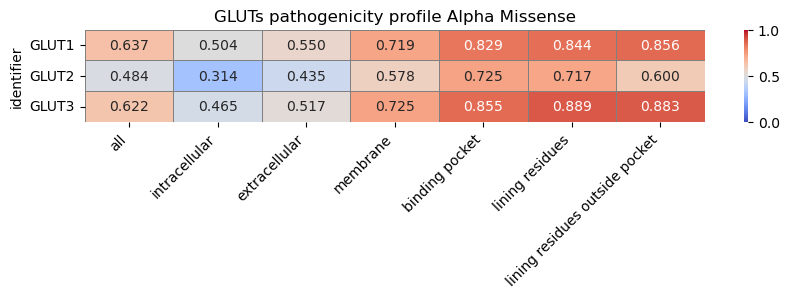

In [25]:
#Creating the final heatmap
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Loading file
df = pd.read_csv(AM_DIR / 'united_averages.csv')

# Setting 'filename' as index
df.set_index("identifier", inplace=True)

# Creating a heat map with values
plt.figure(figsize=(10, len(df) * 0.4))
sns.heatmap(
    df,
    cmap="coolwarm",
    vmin=0,
    vmax=1,
    linewidths=0.5,
    linecolor='gray',
    annot=True,
    fmt=".3f"  
)


plt.title("GLUTs pathogenicity profile Alpha Missense", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()


plt.savefig("heatmap_patogenicityPyMissense.png", dpi=300, bbox_inches='tight')

plt.show()